<a href="https://colab.research.google.com/github/Jbrr2021/Python-Kaggle-V-cio-em-redes-sociais/blob/main/exercicios_python_kaggle_v_cio_em_redes_sociais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Conjunto de dados sobre vício em redes sociais e produtividade

Um conjunto de dados realista que analisa o impacto do uso das redes sociais na produtividade.

## Visão geral

Este conjunto de dados explora a relação entre o uso de redes sociais e os níveis de produtividade entre indivíduos.

Ele reúne características comportamentais, hábitos de vida e padrões de atividade digital, simulando situações próximas do mundo real.

## Objetivo

O principal objetivo deste conjunto de dados é analisar como o uso de redes sociais pode estar associado à produtividade.

Com ele, é possível:

- investigar padrões de comportamento digital
- analisar fatores relacionados ao foco e à produtividade
- criar modelos de aprendizado de máquina para prever a pontuação de produtividade
- classificar os níveis de dependência em redes sociais

## Variáveis do conjunto de dados

- **age**: idade do indivíduo
- **daily_screen_time**: tempo total de uso de tela por dia, em horas
- **social_media_hours**: tempo gasto em redes sociais, em horas
- **study_hours**: tempo produtivo dedicado a estudo ou trabalho
- **sleep_hours**: duração diária do sono
- **notifications_per_day**: número de notificações recebidas por dia
- **focus_score**: pontuação de foco mental, variando de 0 a 100
- **addiction_level**: nível de dependência em redes sociais (`Low`, `Medium`, `High`)
- **productivity_score**: pontuação de produtividade, variando de 0 a 100

## Características dos dados

- 6000 linhas
- presença de valores ausentes em aproximadamente 2% dos dados
- correlações realistas entre variáveis
- adequado para tarefas de análise exploratória, regressão e classificação

## Possíveis aplicações

Este conjunto de dados pode ser utilizado para:

- realizar análise exploratória de dados (EDA)
- estudar o comportamento de dependência digital
- prever produtividade com modelos de aprendizado de máquina
- desenvolver técnicas de tratamento de dados e engenharia de atributos

## Perguntas da análise

Nesta análise, buscarei responder às seguintes perguntas:

1. Níveis mais altos de vício em redes sociais estão associados a menor produtividade?
2. O foco varia de acordo com o nível de dependência?
3. O tempo gasto em redes sociais parece impactar a produtividade?
4. As horas de estudo mudam entre os grupos de dependência?

In [ ]:
import kagglehub
path = kagglehub.dataset_download("asifxzaman/social-media-addiction-vs-productivity-dataset")
print("Path to dataset files: ", path)



Using Colab cache for faster access to the 'social-media-addiction-vs-productivity-dataset' dataset.
Path to dataset files:  /kaggle/input/social-media-addiction-vs-productivity-dataset


In [ ]:
import os
print("Path:", path)
print("Arquivos:")
print(os.listdir(path))

Path: /kaggle/input/social-media-addiction-vs-productivity-dataset
Arquivos:
['social_media_productivity_6000.csv']


In [ ]:
import pandas as pd
import os

arquivo_csv = os.path.join(path, "social_media_productivity_6000.csv")
df = pd.read_csv(arquivo_csv)

df.head()

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score
0,21.0,5.95,2.81,2.61,6.99,283.0,100.00,Medium,28.49
1,34.0,3.82,2.33,0.28,7.47,266.0,93.65,Medium,18.54
2,29.0,3.57,1.64,5.21,6.34,137.0,100.00,Low,68.52
3,25.0,10.27,4.37,4.28,4.49,247.0,94.71,Medium,27.82
4,22.0,2.42,1.60,3.67,6.34,28.0,100.00,Low,51.09


In [ ]:
print(df.shape)
print(df.columns)
df.info()
print(df.describe())
print(df.isnull().sum())

(6000, 9)
Index(['age', 'daily_screen_time', 'social_media_hours', 'study_hours',
       'sleep_hours', 'notifications_per_day', 'focus_score',
       'addiction_level', 'productivity_score'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    5880 non-null   float64
 1   daily_screen_time      5880 non-null   float64
 2   social_media_hours     5880 non-null   float64
 3   study_hours            5880 non-null   float64
 4   sleep_hours            5880 non-null   float64
 5   notifications_per_day  5880 non-null   float64
 6   focus_score            5880 non-null   float64
 7   addiction_level        5880 non-null   object 
 8   productivity_score     5880 non-null   float64
dtypes: float64(8), object(1)
memory usage: 422.0+ KB
               age  daily_screen_time  social_media_h

In [ ]:
# Melhorias visuais nos graficos.
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (8, 5)
media_prod = df.groupby("addiction_level")["productivity_score"].mean().reindex(["Low", "Medium", "High"])

In [ ]:
# 1. Ver os valores da coluna catégorica

df["addiction_level"].value_counts()

,count
addiction_level,
Medium,3064
High,1857
Low,959


In [ ]:
# 2. Ver a correlação entre as colunas numéricas

df.corr(numeric_only=True)

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,productivity_score
age,1.000000,0.008468,0.008792,0.008894,-0.002600,-0.000925,0.006313,0.001007
daily_screen_time,0.008468,1.000000,0.792635,0.002110,0.001509,-0.009636,-0.427081,-0.410432
social_media_hours,0.008792,0.792635,1.000000,0.001457,0.002396,-0.010664,-0.597569,-0.508546
study_hours,0.008894,0.002110,0.001457,1.000000,0.001542,-0.026506,0.404248,0.738955
sleep_hours,-0.002600,0.001509,0.002396,0.001542,1.000000,0.027053,0.175687,0.220922
notifications_per_day,-0.000925,-0.009636,-0.010664,-0.026506,0.027053,1.000000,-0.182124,-0.080977
focus_score,0.006313,-0.427081,-0.597569,0.404248,0.175687,-0.182124,1.000000,0.572190
productivity_score,0.001007,-0.410432,-0.508546,0.738955,0.220922,-0.080977,0.572190,1.000000


In [ ]:
df[["addiction_level", "productivity_score"]].head()

,addiction_level,productivity_score
0,Medium,28.49
1,Medium,18.54
2,Low,68.52
3,Medium,27.82
4,Low,51.09


In [ ]:
df["addiction_level"].unique()

array(['Medium', 'Low', 'High', nan], dtype=object)

In [ ]:
# 3. Ver média de produtividade por nível de vicio
df.groupby("addiction_level")["productivity_score"].agg(["count", "mean"])

,count,mean
addiction_level,,
High,1818,20.319741
Low,942,56.925053
Medium,3002,42.161399


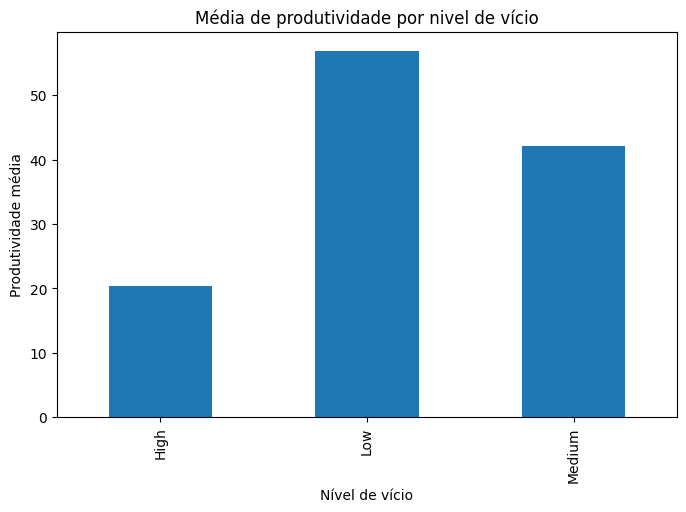

In [ ]:
# 4. Gráfico de barras da produtividade média por nível de vício

import matplotlib.pyplot as plt

media_prod = df.groupby("addiction_level")["productivity_score"].mean()

media_prod.plot(kind="bar")
plt.title("Média de produtividade por nivel de vício")
plt.xlabel("Nível de vício")
plt.ylabel("Produtividade média")
plt.show()


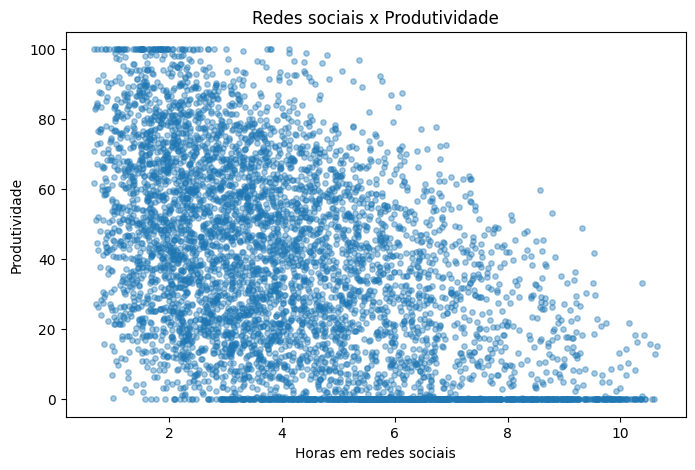

In [ ]:
# 5. Relação entre horas em redes socias e produtividade

import matplotlib.pyplot as plt

dados = df[["social_media_hours", "productivity_score"]].dropna()

plt.scatter(dados["social_media_hours"], dados["productivity_score"], alpha=0.4, s=15)
plt.xlabel("Horas em redes sociais")
plt.ylabel("Produtividade")
plt.title("Redes sociais x Produtividade")
plt.show()

In [ ]:
# 6. Ver a Média de foco por nivel de vício

df.groupby("addiction_level")["focus_score"].mean()

,focus_score
addiction_level,
High,90.779725
Low,99.793828
Medium,98.676560


In [ ]:
# 7. Ver a média de horas em redes sociais por nível de vício

df.groupby("addiction_level")["social_media_hours"].mean()

,social_media_hours
addiction_level,
High,6.784294
Low,1.483836
Medium,3.378540


In [ ]:
# 8. Ver média de horas de estudo por nível de vício

df.groupby("addiction_level")["study_hours"].mean()

,study_hours
addiction_level,
High,4.069659
Low,4.140977
Medium,4.060423


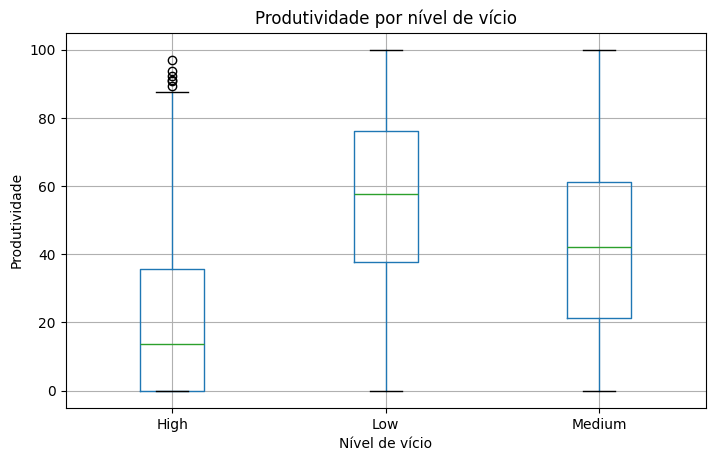

In [ ]:
# 9. Boxplot da produtividade por nível de vício

import matplotlib.pyplot as plt

df.boxplot(column="productivity_score", by="addiction_level")
plt.title("Produtividade por nível de vício")
plt.suptitle("")
plt.xlabel("Nível de vício")
plt.ylabel("Produtividade")
plt.show()

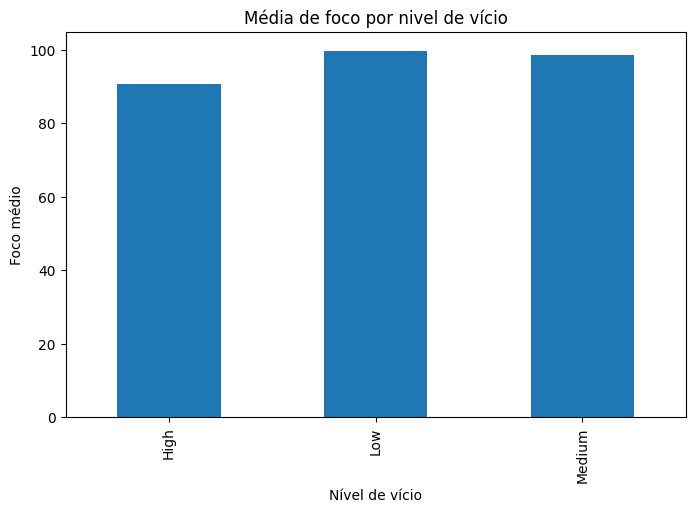

In [ ]:
# 10. Barras de média de foco por nível de vício

media_foco = df.groupby("addiction_level")["focus_score"].mean()

media_foco.plot(kind="bar")
plt.title("Média de foco por nivel de vício")
plt.xlabel("Nível de vício")
plt.ylabel("Foco médio")
plt.show()

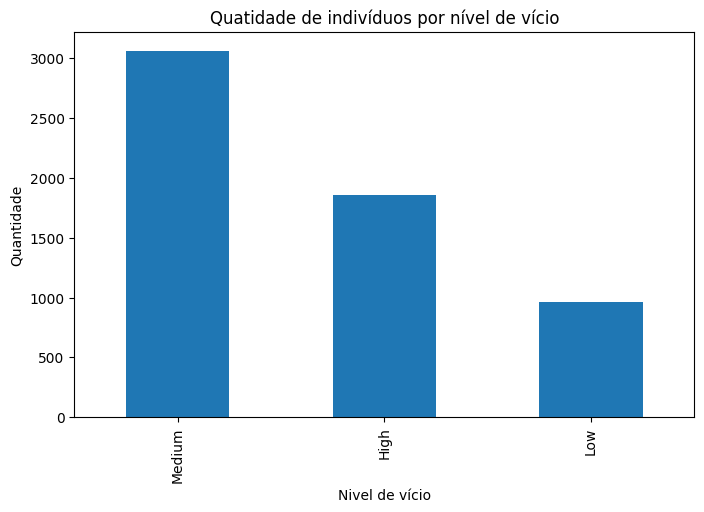

In [ ]:
# 11 Gráfico de quantidade por nivel de vício

df["addiction_level"].value_counts().plot(kind="bar")
plt.title("Quatidade de indivíduos por nível de vício")
plt.xlabel("Nivel de vício")
plt.ylabel("Quantidade")
plt.show()

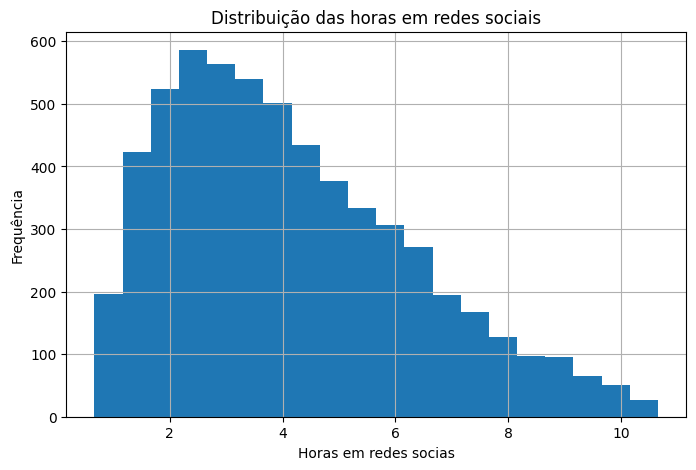

In [ ]:
# 12 Histograma de horas em redes sociais.

df['social_media_hours'].dropna().hist(bins=20)
plt.title("Distribuição das horas em redes sociais")
plt.xlabel("Horas em redes socias")
plt.ylabel("Frequência")
plt.show()

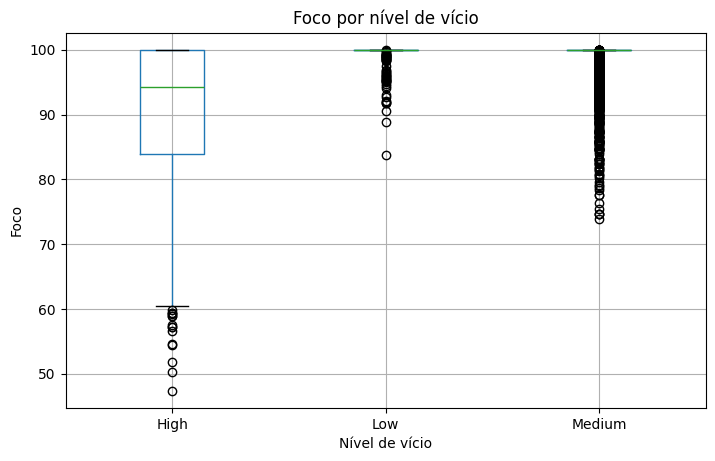

In [ ]:
# 13 Boxplot de foco por nível de vício

df.boxplot(column="focus_score", by="addiction_level")
plt.title("Foco por nível de vício")
plt.suptitle("")
plt.xlabel("Nível de vício")
plt.ylabel("Foco")
plt.show()

In [ ]:
# 14 Faixa etária

bins = [14, 20, 25, 30, 35,40]
labels = ["15-20", "21-25", "26-30", "31-35", "36-40"]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)

df.groupby("age_group")["productivity_score"].mean()

/tmp/ipykernel_8500/564376355.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_group")["productivity_score"].mean()


,productivity_score
age_group,
15-20,38.583388
21-25,35.595867
26-30,38.148931
31-35,38.009958
36-40,37.394564


In [ ]:
print("""
Conclusão inicial:
Os resultados indicam que níveis mais altos de vício em redes sociais estão associados
a menor produtividade e menor foco. Além disso, indivíduos com maior vício passam mais
horas nas redes sociais. Já as horas de estudo apresentaram pouca variação entre os grupos.
""")


Conclusão inicial:
Os resultados indicam que níveis mais altos de vício em redes sociais estão associados
a menor produtividade e menor foco. Além disso, indivíduos com maior vício passam mais
horas nas redes sociais. Já as horas de estudo apresentaram pouca variação entre os grupos.

